### 👥 Kelompok Proyek Rekayasa Data:
1. **235150201111036** DARVESH AZIZ MAWLA
2. **235150207111063** ACHMAD ALVIAN PRASETIO
3. **235150207111006** DZAKY REZANDI
4. **235150201111004** WAHYU DWI LAKSANA PUTRI
5. **235150207111065** JONATHAN SALIM

---

# 🧱 Data Engineering Master Notebook

Notebook ini merangkum **audit teknis**, **pembersihan data**, dan **hasil pipeline** untuk proyek NYC TLC (Jan-Jun 2025) + data cuaca. Fokus utama adalah kualitas data dan kesiapan untuk  analytics.

---

## 1. Setup & Environment

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

DB_PATH = os.path.join("..", "data", "final", "tlc.duckdb")
con = duckdb.connect(DB_PATH, read_only=True)
print(f"✅ Connected to: {os.path.abspath(DB_PATH)}")

✅ Connected to: c:\Users\user\Documents\Kuliah\SEMESTER 6\Rekayasa Data dan Visualisasi\Proyek\Code\RDV-Taxi\data\final\tlc.duckdb


# Raw Data Profiling & Technical Audit
Tujuan: menemukan anomali di data mentah (`tlc_raw`) sebelum dibersihkan.

## 1.1 Validasi Skema
Memeriksa tipe data kolom di `tlc_raw` untuk memastikan konsistensi schema awal.

In [2]:
schema_df = con.execute("PRAGMA table_info('tlc_raw')").df()
display(schema_df)

,cid,name,type,notnull,dflt_value,pk
0,0,VendorID,INTEGER,False,None,False
1,1,tpep_pickup_datetime,TIMESTAMP,False,None,False
2,2,tpep_dropoff_datetime,TIMESTAMP,False,None,False
3,3,passenger_count,BIGINT,False,None,False
4,4,trip_distance,DOUBLE,False,None,False
5,5,RatecodeID,BIGINT,False,None,False
6,6,store_and_fwd_flag,VARCHAR,False,None,False
7,7,PULocationID,INTEGER,False,None,False
8,8,DOLocationID,INTEGER,False,None,False
9,9,payment_type,BIGINT,False,None,False


## 1.2 Null Constraint Check
Mengukur persentase missing values untuk kolom krusial.

In [3]:
critical_columns = ["PULocationID", "DOLocationID", "tpep_pickup_datetime"]
row_count = con.execute("SELECT COUNT(*) FROM tlc_raw").fetchone()[0]

null_rows = []
for col in critical_columns:
    count = con.execute(f"SELECT COUNT(*) FROM tlc_raw WHERE {col} IS NULL").fetchone()[0]
    null_rows.append({"column": col, "null_rows": count, "null_rate": count / row_count if row_count else 0})

null_df = pd.DataFrame(null_rows)
display(null_df)

,column,null_rows,null_rate
0,PULocationID,0,0.0
1,DOLocationID,0,0.0
2,tpep_pickup_datetime,0,0.0


## 1.2A PK/FK Integrity Snapshot
Cek cepat apakah kunci lokasi di `tlc_raw` bisa terhubung dengan dimensi lokasi (dim_location). Ini penting untuk Star Schema dan peta geospasial.

In [4]:
def _get_columns(table_name):
    return con.execute(f"PRAGMA table_info('{table_name}')").df()["name"].tolist()

dim_cols = set(_get_columns("dim_location")) if "dim_location" in con.execute("SHOW TABLES").df()["name"].tolist() else set()
raw_cols = set(_get_columns("tlc_raw"))

location_dim_key = "location_id" if "location_id" in dim_cols else "location_key" if "location_key" in dim_cols else None
pickup_key = "PULocationID" if "PULocationID" in raw_cols else None
dropoff_key = "DOLocationID" if "DOLocationID" in raw_cols else None

join_rows = []
if location_dim_key and pickup_key:
    join_result = con.execute(
        f"""
        SELECT
            COUNT(*) AS total_rows,
            SUM(CASE WHEN l.{location_dim_key} IS NULL THEN 1 ELSE 0 END) AS unmatched_rows
        FROM tlc_raw r
        LEFT JOIN dim_location l
          ON r.{pickup_key} = l.{location_dim_key}
        """
    ).fetchone()
    join_rows.append({
        "join_key": pickup_key,
        "total_rows": int(join_result[0]),
        "unmatched_rows": int(join_result[1] or 0),
        "match_rate": 1.0 - (int(join_result[1] or 0) / int(join_result[0]) if join_result[0] else 0.0),
    })
if location_dim_key and dropoff_key:
    join_result = con.execute(
        f"""
        SELECT
            COUNT(*) AS total_rows,
            SUM(CASE WHEN l.{location_dim_key} IS NULL THEN 1 ELSE 0 END) AS unmatched_rows
        FROM tlc_raw r
        LEFT JOIN dim_location l
          ON r.{dropoff_key} = l.{location_dim_key}
        """
    ).fetchone()
    join_rows.append({
        "join_key": dropoff_key,
        "total_rows": int(join_result[0]),
        "unmatched_rows": int(join_result[1] or 0),
        "match_rate": 1.0 - (int(join_result[1] or 0) / int(join_result[0]) if join_result[0] else 0.0),
    })

fk_df = pd.DataFrame(join_rows)
display(fk_df)

,join_key,total_rows,unmatched_rows,match_rate
0,PULocationID,24083384,0,1.0
1,DOLocationID,24083384,0,1.0


## 1.2B Temporal Anomalies 
Tujuan: memastikan `tpep_pickup_datetime` berada di periode tugas (Jan-Jun 2025). Data di luar rentang akan merusak  waktu time-series.

In [5]:
temporal_sql = """
SELECT
    COUNT(*) AS out_of_range_rows
FROM tlc_raw
WHERE tpep_pickup_datetime < DATE '2025-01-01'
   OR tpep_pickup_datetime >= DATE '2025-07-01'
"""
temporal_df = con.execute(temporal_sql).df()
display(temporal_df)

,out_of_range_rows
0,24


In [6]:
# Tampilkan semua baris out-of-range dan hitung jumlahnya
out_of_range_full_sql = """
SELECT
    tpep_pickup_datetime,
    passenger_count,
    fare_amount,
    trip_distance,
    PULocationID,
    DOLocationID
FROM tlc_raw
WHERE tpep_pickup_datetime < DATE '2025-01-01'
   OR tpep_pickup_datetime >= DATE '2025-07-01'
ORDER BY tpep_pickup_datetime
"""
out_of_range_full_df = con.execute(out_of_range_full_sql).df()
display(out_of_range_full_df)
print(f"Jumlah baris out_of_range: {len(out_of_range_full_df)}")

,tpep_pickup_datetime,passenger_count,fare_amount,trip_distance,PULocationID,DOLocationID
0,2007-12-05 18:45:00,1,17.0,3.00,142,234
1,2009-01-01 00:19:34,6,52.7,10.77,138,239
2,2009-01-01 00:20:39,5,24.0,4.47,230,261
3,2024-12-31 20:47:55,2,9.3,1.72,48,246
4,2024-12-31 20:52:50,2,23.3,5.05,249,262
5,2024-12-31 20:54:50,2,28.2,1.39,246,48
6,2024-12-31 21:15:22,2,15.6,3.20,141,146
7,2024-12-31 21:20:05,2,16.3,2.64,42,238
8,2024-12-31 21:33:43,2,7.9,1.12,179,7
9,2024-12-31 23:24:31,5,3.7,0.28,132,132


Jumlah baris out_of_range: 24


## 1.2C Financial Anomalies (Uang Tidak Masuk Akal)
Tujuan: menemukan tarif bernilai 0 atau negatif agar total revenue tidak bias karena refund/pembatalan.

In [7]:
financial_sql = """
SELECT
    SUM(CASE WHEN fare_amount <= 0 THEN 1 ELSE 0 END) AS non_positive_fare,
    SUM(CASE WHEN total_amount <= 0 THEN 1 ELSE 0 END) AS non_positive_total
FROM tlc_raw
"""
financial_df = con.execute(financial_sql).df()
display(financial_df)

,non_positive_fare,non_positive_total
0,1333063.0,449678.0


In [8]:
# Anomali uang + jumlah + rangkuman jenis anomali
money_anomaly_sql = """
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN fare_amount < 0 THEN 1 ELSE 0 END) AS negative_fare,
    SUM(CASE WHEN fare_amount = 0 THEN 1 ELSE 0 END) AS zero_fare,
    SUM(CASE WHEN fare_amount <= 0 THEN 1 ELSE 0 END) AS non_positive_fare,
    SUM(CASE WHEN total_amount < 0 THEN 1 ELSE 0 END) AS negative_total,
    SUM(CASE WHEN total_amount = 0 THEN 1 ELSE 0 END) AS zero_total,
    SUM(CASE WHEN total_amount <= 0 THEN 1 ELSE 0 END) AS non_positive_total
FROM tlc_raw
"""
money_anomaly_df = con.execute(money_anomaly_sql).df()
display(money_anomaly_df)

# Ubah ke format ringkas agar mudah dibaca
summary_cols = [
    "negative_fare",
    "zero_fare",
    "non_positive_fare",
    "negative_total",
    "zero_total",
    "non_positive_total",
]
money_anomaly_summary_df = (
    money_anomaly_df[summary_cols]
    .T.reset_index()
    .rename(columns={"index": "anomaly_type", 0: "anomaly_count"})
)

total_rows_local = int(money_anomaly_df.loc[0, "total_rows"])
money_anomaly_summary_df["anomaly_rate_pct"] = (
    money_anomaly_summary_df["anomaly_count"] / total_rows_local * 100
).round(4)

desc_map = {
    "negative_fare": "fare_amount < 0 (refund/koreksi)",
    "zero_fare": "fare_amount = 0",
    "non_positive_fare": "fare_amount <= 0",
    "negative_total": "total_amount < 0",
    "zero_total": "total_amount = 0",
    "non_positive_total": "total_amount <= 0",
}
money_anomaly_summary_df["description"] = money_anomaly_summary_df["anomaly_type"].map(desc_map)

display(money_anomaly_summary_df.sort_values("anomaly_count", ascending=False))

print(f"Total baris data: {total_rows_local:,}")
print(f"Total event anomali uang (penjumlahan semua tipe): {int(money_anomaly_summary_df['anomaly_count'].sum()):,}")

,total_rows,negative_fare,zero_fare,non_positive_fare,negative_total,zero_total,non_positive_total
0,24083384,1323048.0,10015.0,1333063.0,446311.0,3367.0,449678.0


,anomaly_type,anomaly_count,anomaly_rate_pct,description
2,non_positive_fare,1333063.0,5.5352,fare_amount <= 0
0,negative_fare,1323048.0,5.4936,fare_amount < 0 (refund/koreksi)
5,non_positive_total,449678.0,1.8672,total_amount <= 0
3,negative_total,446311.0,1.8532,total_amount < 0
1,zero_fare,10015.0,0.0416,fare_amount = 0
4,zero_total,3367.0,0.0140,total_amount = 0


Total baris data: 24,083,384
Total event anomali uang (penjumlahan semua tipe): 3,565,482


## 1.2D Physical/Logic Anomalies 
Tujuan: menghapus perjalanan yang tidak masuk akal (misal taksi tidak bergerak atau tanpa penumpang) agar analisis jarak dan demand akurat.

In [9]:
logic_sql = """
SELECT
    SUM(CASE WHEN trip_distance = 0 THEN 1 ELSE 0 END) AS zero_distance,
    SUM(CASE WHEN passenger_count = 0 THEN 1 ELSE 0 END) AS zero_passenger
FROM tlc_raw
"""
logic_df = con.execute(logic_sql).df()
display(logic_df)

,zero_distance,zero_passenger
0,661842.0,138981.0


In [10]:
logic_evidence_sql = """
SELECT
    tpep_pickup_datetime,
    tpep_dropoff_datetime,
    passenger_count,
    trip_distance,
    fare_amount,
    total_amount,
    PULocationID,
    DOLocationID,
    CASE
        WHEN trip_distance = 0 AND passenger_count = 0 THEN 'zero_distance_and_zero_passenger'
        WHEN trip_distance = 0 THEN 'zero_distance'
        WHEN passenger_count = 0 THEN 'zero_passenger'
    END AS anomaly_type
FROM tlc_raw
WHERE trip_distance = 0
   OR passenger_count = 0
ORDER BY
    CASE
        WHEN trip_distance = 0 AND passenger_count = 0 THEN 1
        WHEN trip_distance = 0 THEN 2
        ELSE 3
    END,
    tpep_pickup_datetime
LIMIT 20
"""

logic_evidence_df = con.execute(logic_evidence_sql).df()
display(logic_evidence_df)

logic_evidence_count_sql = """
SELECT
    SUM(CASE WHEN trip_distance = 0 THEN 1 ELSE 0 END) AS zero_distance_rows,
    SUM(CASE WHEN passenger_count = 0 THEN 1 ELSE 0 END) AS zero_passenger_rows,
    SUM(CASE WHEN trip_distance = 0 AND passenger_count = 0 THEN 1 ELSE 0 END) AS both_conditions_rows
FROM tlc_raw
"""

logic_evidence_count_df = con.execute(logic_evidence_count_sql).df()
display(logic_evidence_count_df)

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID,anomaly_type
0,2025-01-01 00:42:42,2025-01-01 00:42:44,0,0.0,3.00,10.35,261,261,zero_distance_and_zero_passenger
1,2025-01-01 01:42:36,2025-01-01 01:44:12,0,0.0,3.70,8.70,164,164,zero_distance_and_zero_passenger
2,2025-01-01 01:45:42,2025-01-01 01:45:57,0,0.0,15.20,19.20,140,140,zero_distance_and_zero_passenger
3,2025-01-01 01:47:54,2025-01-01 01:48:13,0,0.0,15.20,24.00,140,140,zero_distance_and_zero_passenger
4,2025-01-01 02:24:16,2025-01-01 02:24:19,0,0.0,3.00,40.00,170,170,zero_distance_and_zero_passenger
5,2025-01-01 04:52:28,2025-01-02 04:50:46,0,0.0,-12.40,-16.40,233,233,zero_distance_and_zero_passenger
6,2025-01-01 04:52:28,2025-01-02 04:50:46,0,0.0,12.40,16.40,233,233,zero_distance_and_zero_passenger
7,2025-01-01 07:58:59,2025-01-01 07:59:22,0,0.0,3.00,4.50,145,145,zero_distance_and_zero_passenger
8,2025-01-01 12:53:45,2025-01-01 12:53:45,0,0.0,21.55,21.55,164,264,zero_distance_and_zero_passenger
9,2025-01-01 17:17:57,2025-01-01 17:17:57,0,0.0,26.15,26.15,42,264,zero_distance_and_zero_passenger


,zero_distance_rows,zero_passenger_rows,both_conditions_rows
0,661842.0,138981.0,5589.0


## 1.2E Referential Integrity (ID Lokasi)
Tujuan: memastikan `PULocationID` dan `DOLocationID` berada di rentang 1-265 sesuai taxi_zone_lookup.csv, agar join ke dimensi lokasi tidak gagal.

In [11]:
location_range_sql = """
SELECT
    SUM(CASE WHEN PULocationID < 1 OR PULocationID > 265 THEN 1 ELSE 0 END) AS invalid_pickup_id,
    SUM(CASE WHEN DOLocationID < 1 OR DOLocationID > 265 THEN 1 ELSE 0 END) AS invalid_dropoff_id
FROM tlc_raw
"""
location_range_df = con.execute(location_range_sql).df()
display(location_range_df)

,invalid_pickup_id,invalid_dropoff_id
0,0.0,0.0


## 1.3 Ringkasan Temuan Audit
Bagian ini merangkum hasil audit pada 1.2A-1.2E agar mudah dibaca tanpa mengulang kueri.

Poin ringkas:
- Validasi kunci lokasi: cek kecocokan dengan dimensi dan rentang 1-265.
- Anomali temporal: cek tanggal di luar Jan-Jun 2025.
- Anomali finansial: fare/total <= 0 (refund/pembatalan).
- Anomali fisik: jarak 0 atau penumpang 0.

Jika ada nilai besar pada poin-poin di atas, data wajib dibersihkan sebelum masuk Star Schema.

# Transformation & Cleaning Process
Tujuan: menunjukkan tindakan korektif (ELT) untuk mengatasi temuan di Cell sebelumnya.

## 2.1 Strategi Transformasi
Strategi utama:
1. Filter anomali (tarif negatif, penumpang 0, jarak negatif).
2. Casting tipe data waktu dan numerik agar konsisten.
3. Feature engineering untuk atribut turunan seperti durasi perjalanan.

## 2.2 Contoh Pembuatan Kolom Turunan
Menghitung durasi perjalanan dari pickup hingga dropoff.

In [12]:
derived_sql = """
SELECT
    pickup_datetime,
    dropoff_datetime,
    DATE_DIFF('minute', pickup_datetime, dropoff_datetime) AS trip_duration_min
FROM tlc_cleaned
WHERE pickup_datetime IS NOT NULL
  AND dropoff_datetime IS NOT NULL
LIMIT 10
"""
derived_df = con.execute(derived_sql).df()
display(derived_df)

,pickup_datetime,dropoff_datetime,trip_duration_min
0,2025-01-08 13:49:09,2025-01-08 14:01:35,12
1,2025-01-08 13:09:40,2025-01-08 13:41:16,32
2,2025-01-08 13:42:36,2025-01-08 14:02:01,20
3,2025-01-08 13:07:21,2025-01-08 13:19:05,12
4,2025-01-08 13:26:24,2025-01-08 13:41:13,15
5,2025-01-08 13:46:19,2025-01-08 13:57:52,11
6,2025-01-08 13:28:40,2025-01-08 13:38:52,10
7,2025-01-08 13:03:26,2025-01-08 13:12:20,9
8,2025-01-08 13:48:15,2025-01-08 13:51:47,3
9,2025-01-08 13:08:50,2025-01-08 13:25:17,17


# Pipeline Output & Data Retention
Tujuan: bukti keberhasilan pembersihan data dan serah-terima data siap pakai.

## 3.1 Data Retention
Membandingkan jumlah data pada setiap tahap pipeline.

C:\Users\user\AppData\Local\Temp\ipykernel_23168\503222071.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=retention_df, x='stage', y='row_count', palette='Set2')


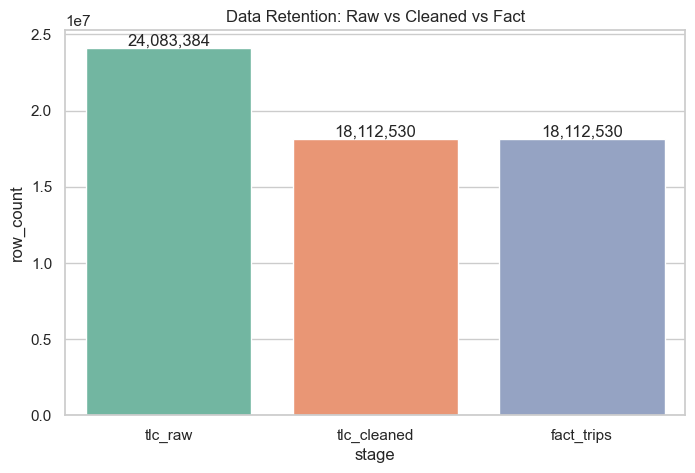

In [13]:
retention_sql = """
SELECT 'tlc_raw' AS stage, COUNT(*) AS row_count FROM tlc_raw
UNION ALL
SELECT 'tlc_cleaned' AS stage, COUNT(*) AS row_count FROM tlc_cleaned
UNION ALL
SELECT 'fact_trips' AS stage, COUNT(*) AS row_count FROM fact_trips
"""
retention_df = con.execute(retention_sql).df()

plt.figure(figsize=(8, 5))
sns.barplot(data=retention_df, x='stage', y='row_count', palette='Set2')
plt.title('Data Retention: Raw vs Cleaned vs Fact')
for i, v in enumerate(retention_df['row_count']):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')
plt.show()

## 3.2 Handover: Ringkasan Star Schema
Menampilkan daftar tabel Fact & Dimension sebagai bukti data siap dipakai oleh tim Data Analyst.

In [14]:
tables_df = con.execute("SHOW TABLES").df()
display(tables_df)

,name
0,dim_location
1,dim_time
2,dim_weather
3,fact_trips
4,taxi_zone_lookup
5,tlc_cleaned
6,tlc_loaded_files
7,tlc_raw
8,weather_raw
9,weather_transformed
